# Exercise 1
## Support Vector Machines
Perception is an important step for autonomous systems. We will look into one method of classifying data given a dataset containing inputs and corresponding targets. In this case we will look at the [Iris dataset](https://en.wikipedia.org/wiki/Iris_flower_data_set), but it could be any arbitrary dataset.

Today we will work with classification using [Support Vector Machines (SVM)](https://en.wikipedia.org/wiki/Support-vector_machine).
We will use the implementation from the `sklearn` library. 

**Note**: If the import of the `pandas` library fails because the module isn't installed, install the `pandas` library with pip.

In [1]:
import sklearn as sk
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
import numpy as np

# Helper function for plotting the fit of your SVM.
def plot_fit(X, y, clf):
    """
    X = samples
    y = Ground truth
    clf = trained model
    """
    h = .02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])

    # Put the result into a color plot
    Z = Z.reshape(xx.shape)
    fig = plt.figure(1, figsize=(8, 6))
    plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)

    # Plot also the training points
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors= "black")
    plt.xlabel('Sepal length')
    plt.ylabel('Sepal width')
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.xticks(())
    plt.yticks(())

As mentioned previously, we're using the Iris dataset. It consists of 150 samples with 4 featuers each.
We're using the sepal length and the sepal width as features to predict which species of the Iris flower one sample is.
The target classes are integer-encoded.

In [2]:
# Import some data to play with
iris = sk.datasets.load_iris()
iris_df = pd.DataFrame(iris.data, columns = iris.feature_names)
display(iris_df)
X = iris_df.iloc[:,:2]
display(X)
y = iris.target
print("Number of samples ::", X.shape[0])
print("Number of features ::", X.shape[1])

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


,sepal length (cm),sepal width (cm)
0,5.1,3.5
1,4.9,3.0
2,4.7,3.2
3,4.6,3.1
4,5.0,3.6
...,...,...
145,6.7,3.0
146,6.3,2.5
147,6.5,3.0
148,6.2,3.4


Number of samples :: 150
Number of features :: 2


## Pandas
We will use pandas to manage our data.
Initially we will only use the two first data points, i.e. the sepal length and sepal width.

We plot the data and we can see all our samples

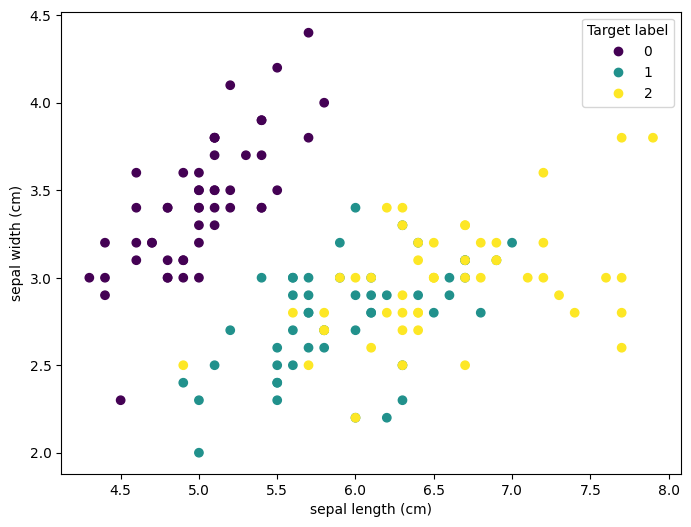

In [3]:
fig1 = plt.figure(1, figsize=(8, 6))
ax = plt.scatter(X['sepal length (cm)'], X["sepal width (cm)"], c=y)
plt.xlabel('sepal length (cm)')
plt.ylabel("sepal width (cm)")
plt.legend(*ax.legend_elements(), title='Target label')
plt.show()

## Normalization.
Using `sklearn.preprocessing` we can normalize the data to have zero mean and unitary variance.
Why could that be important?
```{Python}
X_scaled = StandardScaler().fit_transform(X)
```
Plot the data, did you succed with normalizing the data?



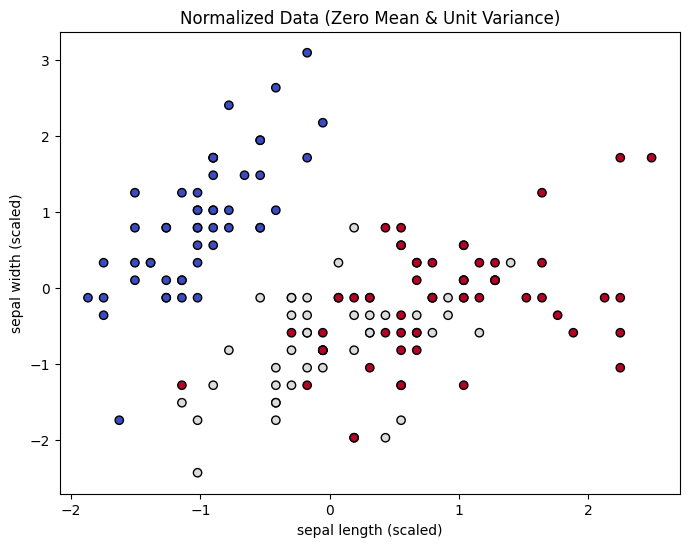

Mean of each feature after scaling: [-1.69031455e-15 -1.84297022e-15]
Std deviation of each feature after scaling: [1. 1.]


In [4]:
###
# code here
###
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Normalize the two selected features
X_scaled = StandardScaler().fit_transform(X)

# Plot normalized data
plt.figure(figsize=(8, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors="black")
plt.xlabel("sepal length (scaled)")
plt.ylabel("sepal width (scaled)")
plt.title("Normalized Data (Zero Mean & Unit Variance)")
plt.show()

# Verify normalization numerically
print("Mean of each feature after scaling:", X_scaled.mean(axis=0))
print("Std deviation of each feature after scaling:", X_scaled.std(axis=0))


### Training / testing split.
We now create a training and testing set.
The training set is to train our model and the testing set is to make sure we don't overfit to the data. We can use the test set to analyze this.

You can use the following function to create your training and testing split:
```{Python}
train_test_split(data, target, test_size=n)
```

In [5]:
###
# code here
###
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets (e.g., 75% train, 25% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42, stratify=y
)

# Print shapes to verify split
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("Training samples:", len(y_train))
print("Testing samples:", len(y_test))


Training set shape: (112, 2)
Test set shape: (38, 2)
Training samples: 112
Testing samples: 38


## Train and test the accuracy of your model
Using `LinearSVC` from `sklearn`:
```{Python}
sk.svm.LinearSVC(penalty='l2', loss='squared_hinge', random_state=0, max_iter=10e4)
```
[Documentation for LinearSVC](https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html?highlight=linearsvc#sklearn.svm.LinearSVC)

You can test the accuracy of your trained model with:
```{}
clf.score(X_train, y_train)
clf.score(X_test, y_test)
```

And finally, plot your fit with the provided plot function `plot_fit`

Training accuracy: 0.786
Testing accuracy: 0.763


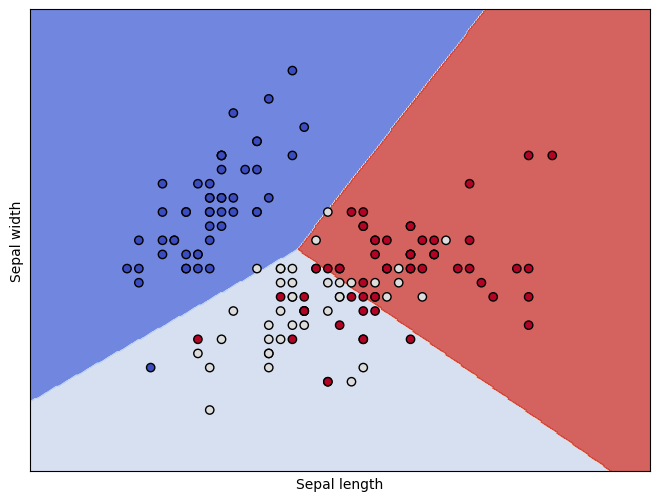

In [6]:
###
# Code goes here
###
from sklearn.svm import LinearSVC

# Create and train the model
clf = LinearSVC(penalty='l2', loss='squared_hinge', random_state=0, max_iter=10_000)
clf.fit(X_train, y_train)

# Evaluate accuracy
train_accuracy = clf.score(X_train, y_train)
test_accuracy = clf.score(X_test, y_test)

print(f"Training accuracy: {train_accuracy:.3f}")
print(f"Testing accuracy: {test_accuracy:.3f}")

# Plot decision boundary using the provided helper
plot_fit(X_scaled, y, clf)


## Exercises
### 1) Kernel
First exersice is to try other kernels than the linear:
```{python}
svc = svm.SVC(kernel='linear', C=C)
rbf_svc = svm.SVC(kernel='rbf', gamma=gamma, C=C))
poly_svc = svm.SVC(kernel='poly', degree=degree, C=C))
```
[SVC documentation](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html)

Do you get better results?
### 2 ) More dimensions
Now use 3 features for each sample. So either you add the petal length or petal width as an additional feature.

Can you get a better fit?

Can you visualize your predictions? 
Make a 3D scatterplot with colors for each predicted class.
```{Python}
fig = plt.figure(1, figsize=(10, 8))
ax = Axes3D(fig, elev=-150, azim=110)
ax.scatter(x, y, z, c=class_vector)
```

### 3) Even more dimensions
Finally try fitting the classifier with all features, i.e. 4 features per sample.

SVC-linear: Train Accuracy = 0.795 | Test Accuracy = 0.711
SVC-RBF: Train Accuracy = 0.812 | Test Accuracy = 0.711
SVC-Poly: Train Accuracy = 0.786 | Test Accuracy = 0.658


C:\Users\UPASANA\AppData\Local\Temp\ipykernel_3408\3616465079.py:27: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  fig = plt.figure(1, figsize=(8, 6))
C:\Users\UPASANA\AppData\Local\Temp\ipykernel_3408\3616465079.py:27: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  fig = plt.figure(1, figsize=(8, 6))


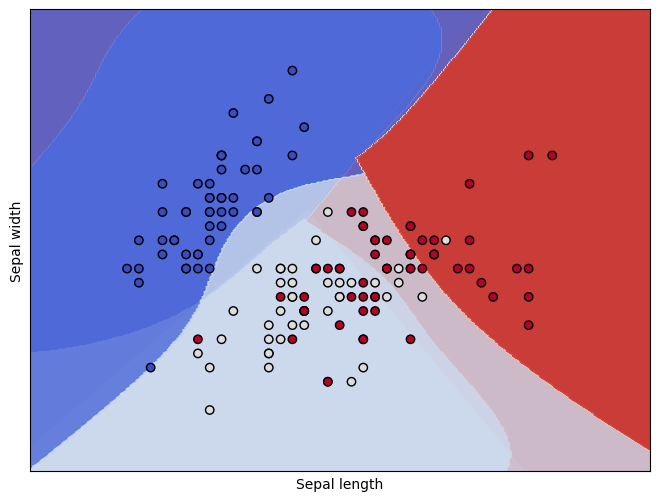

In [8]:
###
# Exercise 1: Try other kernels than the linear
###

from sklearn import svm

# Define hyperparameters
C = 1.0
gamma = "scale"    # default value works well
degree = 3         # for polynomial kernel

# Define SVM models with different kernels
svc_linear = svm.SVC(kernel="linear", C=C, random_state=0)
svc_rbf = svm.SVC(kernel="rbf", gamma=gamma, C=C, random_state=0)
svc_poly = svm.SVC(kernel="poly", degree=degree, C=C, random_state=0)

# Store models for iteration
models = [
    ("SVC-linear", svc_linear),
    ("SVC-RBF", svc_rbf),
    ("SVC-Poly", svc_poly)
]

# Train, evaluate, and visualize each model
for name, clf in models:
    clf.fit(X_train, y_train)
    
    train_acc = clf.score(X_train, y_train)
    test_acc = clf.score(X_test, y_test)
    
    print(f"{name}: Train Accuracy = {train_acc:.3f} | Test Accuracy = {test_acc:.3f}")
    
    # Plot decision boundary using provided function
    plot_fit(X_scaled, y, clf)


3 features (petal length (cm)) – Train acc: 0.955 | Test acc: 0.895


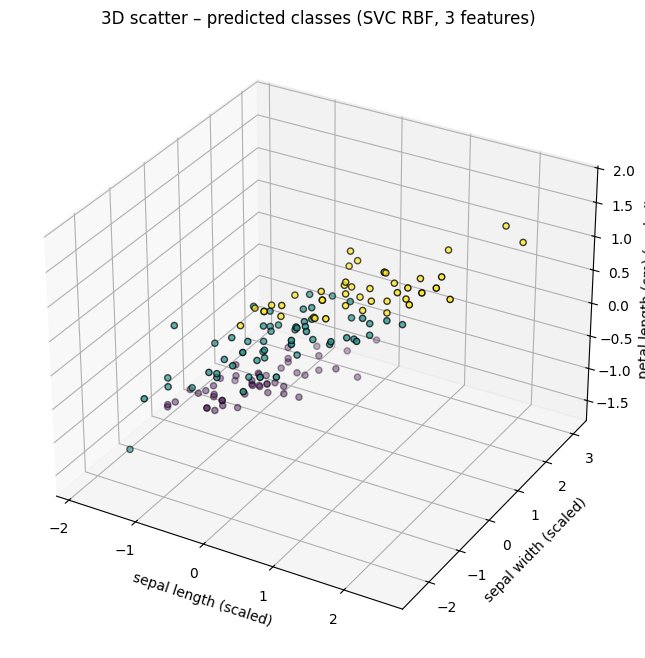

In [9]:
###
# Exercise 2: Use 3 features and visualize predictions in 3D
###

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (needed for 3D projection)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import svm

# ---- Choose the third feature ----
# Option A (default): add "petal length (cm)"
third_feature = "petal length (cm)"
# Option B: uncomment to use petal width instead
# third_feature = "petal width (cm)"

# Build 3-feature matrix
X3 = iris_df[["sepal length (cm)", "sepal width (cm)", third_feature]].values

# Scale
scaler3 = StandardScaler()
X3_scaled = scaler3.fit_transform(X3)

# Split (keep class balance)
X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3_scaled, y, test_size=0.25, random_state=42, stratify=y
)

# Train SVM (RBF is a strong default in higher dimensions)
clf3 = svm.SVC(kernel="rbf", gamma="scale", C=1.0, random_state=0)
clf3.fit(X3_train, y3_train)

# Accuracy
print(f"3 features ({third_feature}) – Train acc: {clf3.score(X3_train, y3_train):.3f} | "
      f"Test acc: {clf3.score(X3_test, y3_test):.3f}")

# Predict all points for visualization
y3_pred = clf3.predict(X3_scaled)

# 3D scatter of predicted classes
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(
    X3_scaled[:, 0],  # sepal length
    X3_scaled[:, 1],  # sepal width
    X3_scaled[:, 2],  # chosen third feature
    c=y3_pred,
    edgecolors="black"
)
ax.set_xlabel("sepal length (scaled)")
ax.set_ylabel("sepal width (scaled)")
ax.set_zlabel(f"{third_feature} (scaled)")
ax.set_title("3D scatter – predicted classes (SVC RBF, 3 features)")
plt.show()


Feature means after scaling (should be ~0): [-1.69031455e-15 -1.84297022e-15 -1.69864123e-15 -1.40924309e-15]
Feature std devs after scaling (should be ~1): [1. 1. 1. 1.]
SVC (RBF, 4 features) – Train: 0.964 | Test: 0.947
LinearSVC (4 features) – Train: 0.964 | Test: 0.868


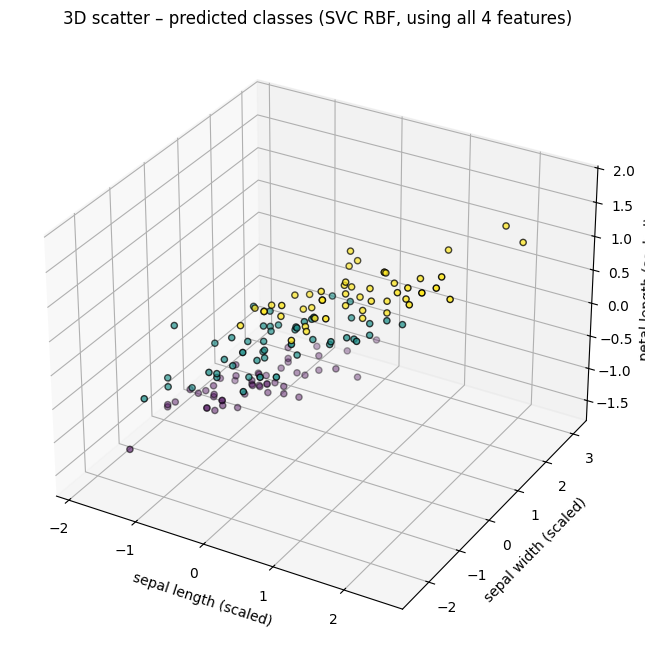

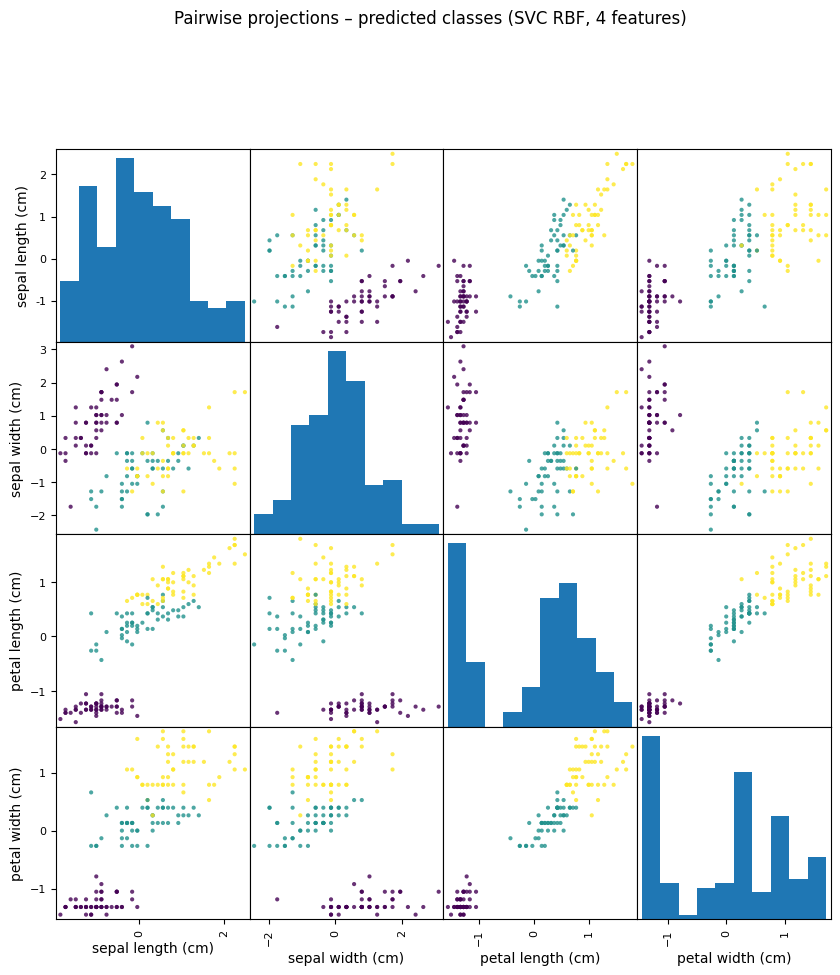

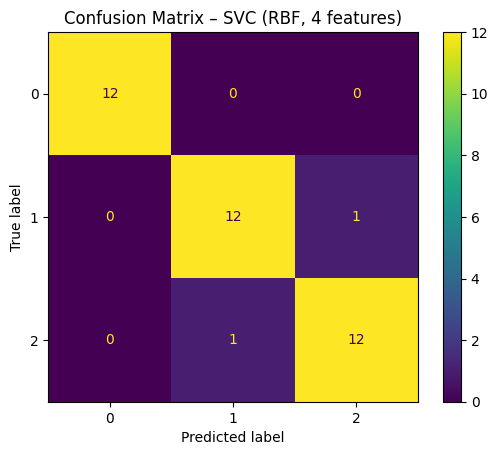

In [11]:
###
# Exercise 3: All four features + plots
###

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from pandas.plotting import scatter_matrix

from sklearn import datasets, svm
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import ConfusionMatrixDisplay

# -----------------------------
# Load data (all 4 features)
# -----------------------------
iris = datasets.load_iris()
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

# -----------------------------
# Scale features
# -----------------------------
scaler4 = StandardScaler()
X4_scaled = scaler4.fit_transform(iris_df.values)

print("Feature means after scaling (should be ~0):", X4_scaled.mean(axis=0))
print("Feature std devs after scaling (should be ~1):", X4_scaled.std(axis=0))

# -----------------------------
# Train/test split
# -----------------------------
X4_train, X4_test, y4_train, y4_test = train_test_split(
    X4_scaled, y, test_size=0.25, random_state=42, stratify=y
)

# -----------------------------
# Train models (RBF SVC + LinearSVC)
# -----------------------------
clf_rbf4 = svm.SVC(kernel="rbf", gamma="scale", C=1.0, random_state=0)
clf_rbf4.fit(X4_train, y4_train)

clf_lin4 = LinearSVC(penalty="l2", loss="squared_hinge", random_state=0, max_iter=100_000)
clf_lin4.fit(X4_train, y4_train)

print(f"SVC (RBF, 4 features) – Train: {clf_rbf4.score(X4_train, y4_train):.3f} | Test: {clf_rbf4.score(X4_test, y4_test):.3f}")
print(f"LinearSVC (4 features) – Train: {clf_lin4.score(X4_train, y4_train):.3f} | Test: {clf_lin4.score(X4_test, y4_test):.3f}")

# -----------------------------
# Visualizations
# -----------------------------

# (A) 3D scatter of first 3 features, colored by predicted class from the 4D RBF model
y4_pred_all = clf_rbf4.predict(X4_scaled)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(
    X4_scaled[:, 0],  # sepal length
    X4_scaled[:, 1],  # sepal width
    X4_scaled[:, 2],  # petal length
    c=y4_pred_all, edgecolors="black"
)
ax.set_xlabel("sepal length (scaled)")
ax.set_ylabel("sepal width (scaled)")
ax.set_zlabel("petal length (scaled)")
ax.set_title("3D scatter – predicted classes (SVC RBF, using all 4 features)")
plt.show()

# (B) Pairwise scatter-matrix of all 4 features, colored by predicted class
df_plot = pd.DataFrame(X4_scaled, columns=iris.feature_names)
df_plot["Predicted"] = y4_pred_all

# Pandas' scatter_matrix (matplotlib backend)
_ = scatter_matrix(
    df_plot[iris.feature_names],
    figsize=(10, 10),
    diagonal="hist",
    c=df_plot["Predicted"].values,   # color by predicted class
    alpha=0.8
)
plt.suptitle("Pairwise projections – predicted classes (SVC RBF, 4 features)", y=1.02)
plt.show()

# (C) Confusion matrix on the test set for quantitative evaluation
ConfusionMatrixDisplay.from_estimator(clf_rbf4, X4_test, y4_test)
plt.title("Confusion Matrix – SVC (RBF, 4 features)")
plt.show()
